# Transforms

> Data transformations and augmentations for 2D and 3D BioImages

In [ ]:
#| default_exp transforms

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import numpy as np
from math import ceil
import cv2
import random
from fastai.vision.all import *
from fastai.data.all import *
from monai.transforms import SpatialCrop, Flip, Rotate90, Spacing, GaussianSmooth, Resize as mResize
from numpy import percentile, isscalar, float32 as np_float32
from skimage.transform import resize

from bioMONAI.data import BioImageBase, BioImageStack, Tensor2BioImage
from bioMONAI.core import img2Tensor

## Size & Sampling

In [ ]:
#| export
class Resample(Transform):
    """
    A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.
    
    The `Resample` class inherits from `Spacing` and provides a flexible way to adjust the spacing (voxel size) of images by specifying either a sampling factor or explicitly providing new voxel dimensions.
    
    """
    
    def __init__(self, sampling, # Sampling factor for isotropic resampling
                 **kwargs, # Additional keyword arguments that can include 'pixdim' to specify custom voxel dimensions
                 ):
        """
        Initializes the Resample class instance.
                    
        If 'pixdim' is provided in kwargs, it will be used directly; otherwise, the sampling factor will determine the new voxel dimensions.
        
        The Spacing class from which Resample inherits is initialized with either the provided pixdim or calculated based on the sampling factor and original image properties.
        """
        if 'pixdim' in kwargs:
            self.spacing = Spacing(**kwargs)
        else:
            self.spacing = Spacing(sampling, **kwargs)
                    
    def encodes(self, img:BioImageBase):
        return type(img)(self.spacing(img))
    
    def encodes(self, img: np.ndarray):
        """Transforms a NumPy array to BioImage and resamples with Spacing."""
        tensor_img = Tensor2BioImage()(img2Tensor(img))
        return self.spacing(tensor_img).numpy()


In [ ]:
from bioMONAI.core import cells3d, img2Tensor
from bioMONAI.visualize import visualize_slices

In [ ]:
img2Tensor(cells3d()[:,0])
Tensor2BioImage()(img2Tensor(cells3d()[:,0]))

BioImageStack([[[0.0314, 0.0314, 0.0324,  ..., 0.0654, 0.0624, 0.0622],
         [0.0306, 0.0298, 0.0310,  ..., 0.0639, 0.0571, 0.0610],
         [0.0300, 0.0351, 0.0292,  ..., 0.0634, 0.0681, 0.0618],
         ...,
         [0.0169, 0.0178, 0.0174,  ..., 0.0412, 0.0439, 0.0493],
         [0.0177, 0.0163, 0.0172,  ..., 0.0455, 0.0498, 0.0521],
         [0.0148, 0.0171, 0.0172,  ..., 0.0419, 0.0464, 0.0543]],

        [[0.0275, 0.0315, 0.0313,  ..., 0.0596, 0.0581, 0.0618],
         [0.0286, 0.0293, 0.0306,  ..., 0.0579, 0.0547, 0.0618],
         [0.0306, 0.0298, 0.0311,  ..., 0.0597, 0.0625, 0.0584],
         ...,
         [0.0188, 0.0164, 0.0151,  ..., 0.0258, 0.0314, 0.0307],
         [0.0137, 0.0195, 0.0141,  ..., 0.0287, 0.0333, 0.0323],
         [0.0143, 0.0182, 0.0159,  ..., 0.0304, 0.0269, 0.0295]],

        [[0.0305, 0.0342, 0.0347,  ..., 0.0563, 0.0589, 0.0569],
         [0.0283, 0.0332, 0.0341,  ..., 0.0618, 0.0594, 0.0602],
         [0.0301, 0.0298, 0.0314,  ..., 0.0570, 0.0

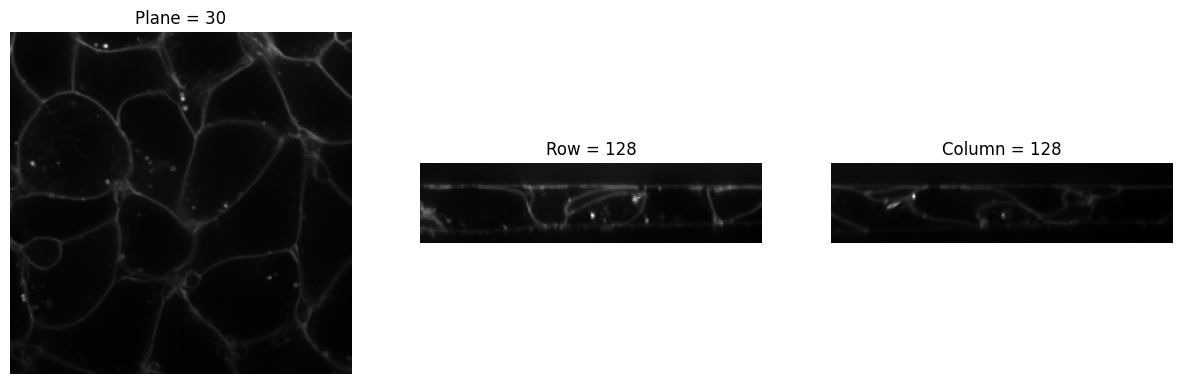

<class 'bioMONAI.data.BioImageStack'>


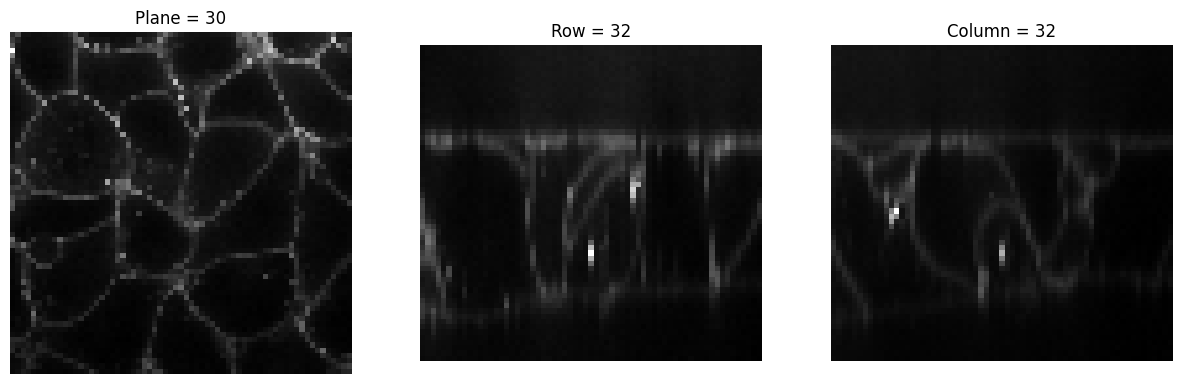

<class 'numpy.ndarray'>


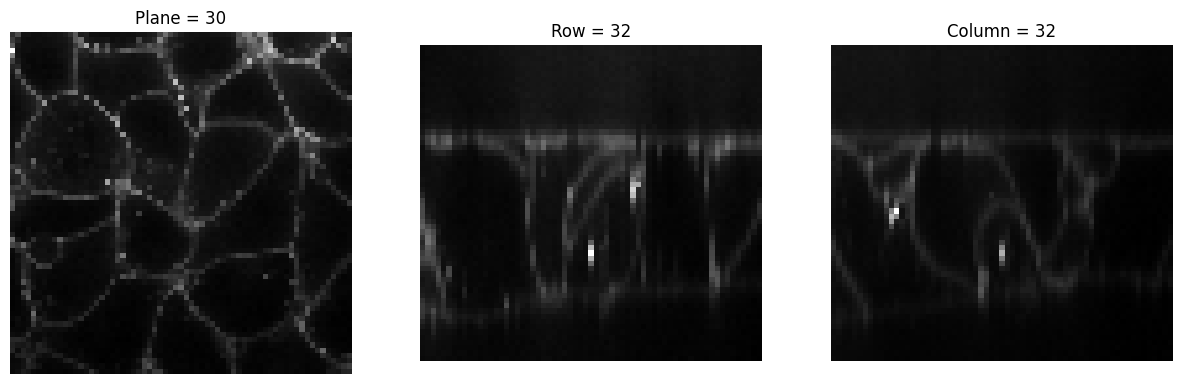

In [ ]:
img = BioImageStack(img2Tensor(cells3d()[:,0]))
visualize_slices(img, showlines=False)

img2 = Resample(4)(img)
print(type(img2))
visualize_slices(img2, showlines=False)

img2 = Resample(4)(cells3d()[:,0])
print(type(img2))
visualize_slices(img2, showlines=False)

In [ ]:
#| export
class Resize(Transform):
    """
    A subclass of Reshape that handles image resizing based on specified target dimensions.

    The `Resize` class inherits from `Reshape` and provides a flexible way to adjust the size of images by specifying either a target size or scaling factors.
    
    """

    def __init__(self, size=None, # Target dimensions for resizing (height, width). If its length is smaller than the spatial dimensions, values will be repeated. If an int is provided, it will be broadcast to all spatial dimensions.
                 **kwargs, # Additional keyword arguments that can include scaling factors or interpolation methods.
                 ):
        """
        Initializes the Resize class instance.

        If 'size' is provided, it will be used directly to resize the image; otherwise, scaling factors or default values will determine the new dimensions.

        The Reshape class from which Resize inherits is initialized with the provided size or calculated dimensions.
        """
        self.size = size
        self.kwargs = kwargs

    def _expand_size(self, size, # The target size provided.
                     spatial_dims, # Number of spatial dimensions in the image.
                     ):
        """
        Expands the size to match the spatial dimensions by repeating values if necessary or broadcasting if size is an int."""
        if size is None:
            return None
        if isinstance(size, int):
            return [size] * spatial_dims
        size = list(size)
        while len(size) < spatial_dims:
            size.extend(size)
        return size[:spatial_dims]

    def encodes(self, img: BioImageBase):
        """
        Resizes the given image to the target dimensions."""
        bioimagetype = type(img)
        spatial_dims = len(img.shape) - 1  # Assuming the first dimension is channels or similar.
        expanded_size = self._expand_size(self.size, spatial_dims)
        reshape_instance = mResize(spatial_size=expanded_size, **self.kwargs)
        return bioimagetype(reshape_instance(img))
    
    def encodes(self, img: np.ndarray):
        """Resizes a NumPy array."""
        spatial_dims = img.ndim - 1  # Assuming first dimension is channels or similar.
        expanded_size = self._expand_size(self.size, spatial_dims)
        return resize(img, expanded_size, **self.kwargs)


torch.Size([60, 256, 256])


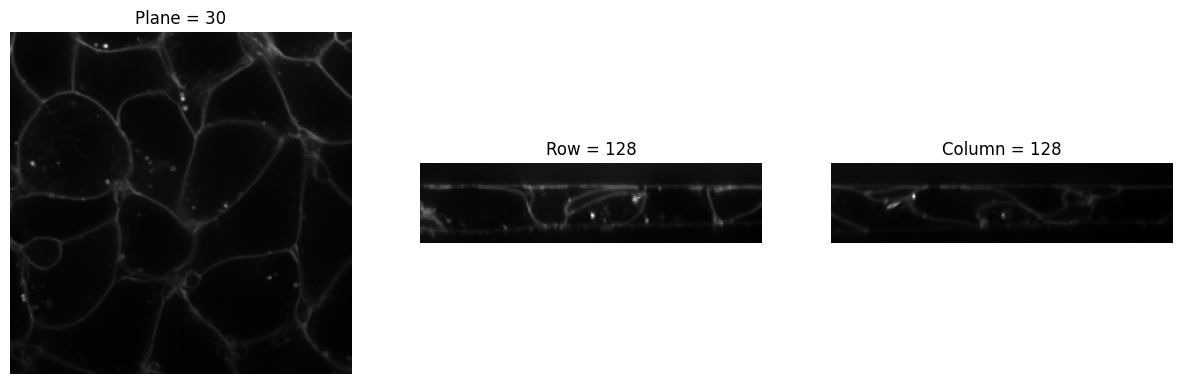

torch.Size([60, 50, 50])


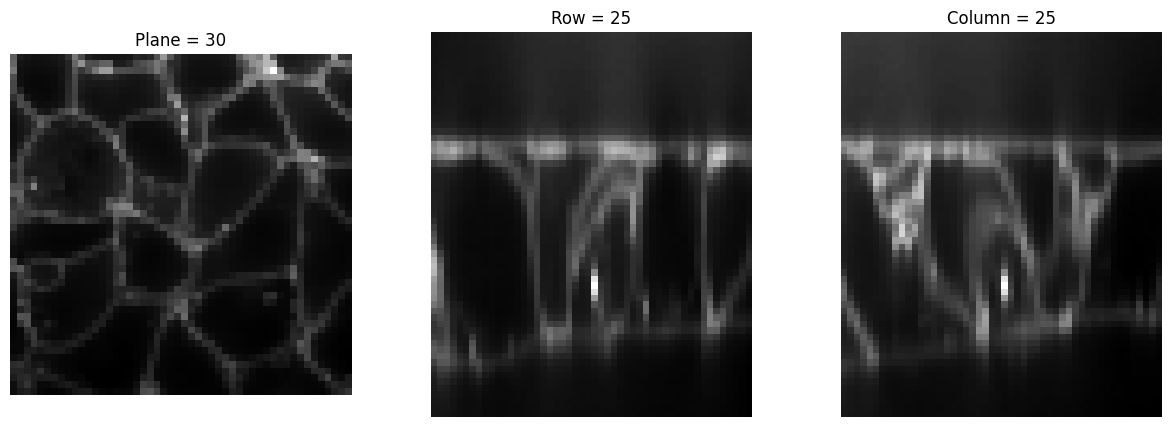

In [ ]:
print(img.size())
visualize_slices(img, showlines=False)

img2 = Resize(50)(img)
print(img2.size())
visualize_slices(img2, showlines=False)

In [ ]:
#| export

class CropND(Transform):
    """
    Crops an ND tensor along a specified dimension.

    This transform crops an ND tensor along specified dimensions, which could be a channel or spatial dimension.
    """
    
    def __init__(self, 
                 slices: list, # List of slice objects or tuples (start, end) for each dimension
                 dims: list = None, # List of dimensions to apply the slices. If None, slices are applied to all dimensions.
                 ):
        self.slices = [slice(*s) if isinstance(s, tuple) else s for s in slices]
        self.dims = dims
        
    def encodes(self, x: BioImageBase):
        """Apply cropping to a BioImageBase object."""
        bioimagetype = type(x)
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return bioimagetype(x[tuple(slices)])
    
    def encodes(self, x: np.ndarray):
        """Apply cropping to a NumPy array."""
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return x[tuple(slices)]

torch.Size([20, 256, 256])


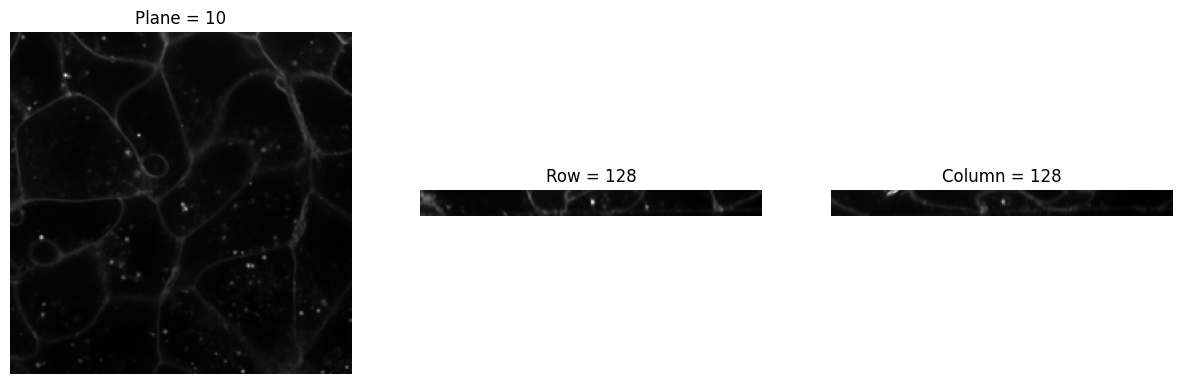

In [ ]:
# Define the slices for cropping
slices = [(30, 50)]

# Create an instance of CropND
crop_transform = CropND(slices=slices)

img3 = crop_transform(img)
print(img3.size())
visualize_slices(img3, showlines=False)

torch.Size([20, 256, 40])


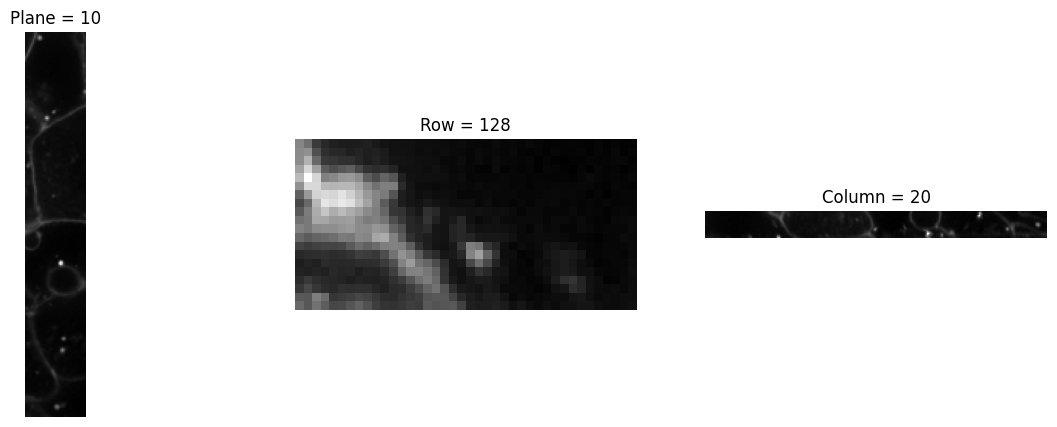

In [ ]:
# Define the slices for cropping
slices = [(30, 50), (0, 40)]
dims = [0, 2]
# Create an instance of CropND
crop_transform = CropND(slices=slices, dims=dims)

img3 = crop_transform(img)
print(img3.size())
visualize_slices(img3, showlines=False)

## Noise

In [ ]:
#| export
class RandCameraNoise(RandTransform):
    """
    Simulates camera noise by adding Poisson shot noise, dark current noise, and optionally CMOS fixed pattern noise.
    
    Returns:
        numpy.ndarray: The noisy image as a NumPy array with dimensions of input_image.
    """
    def __init__(self, p:float=1., # Probability of applying Transform
                 damp=1e-2, # Dampening factor to prevent saturation when adding noise
                 qe=0.7, # Quantum efficiency of the camera (0 to 1).
                 gain=2, # Camera gain factor. If an array, it should be broadcastable with input_image shape. 
                 offset=100, # Camera offset in ADU. If an array, it should be broadcastable with input_image shape. 
                 exp_time=0.1, # Exposure time in seconds. 
                 dark_current=0.6, # Dark current per pixel in electrons/second. 
                 readout=1.5, # Readout noise standard deviation in electrons.
                 bitdepth=16, # Bit depth of the camera output.
                 seed=42, # Seed for random number generator for reproducibility. 
                 simulation=False, # If True, assumes input_image is already in units of photons and does not convert from electrons.
                 camera='cmos', # Specifies the type of camera ('cmos' or any other). Used to add CMOS fixed pattern noise if 'cmos' is specified. 
                 gain_variance=.1, # Variance for the gain noise in CMOS cameras. Only applicable if camera type is 'cmos'. 
                 offset_variance=5 # Variance for the offset noise in CMOS cameras. Only applicable if camera type is 'cmos'.
                 ):
        store_attr()
        self.rs = np.random.RandomState(seed=seed)
        
    def encodes(self, 
               input_image: BioImageBase, # The original image 
               ):
        rs = self.rs
        bioimagetype = type(input_image)
        # If the input image is between 0.0 and 1.0 and bitdepth is specified, rescale it to fit within the bit depth range (0 to 2^bitdepth - 1)
        max_adu = float(2**self.bitdepth - 1)  # Calculate maximum possible ADU value for the given bit depth
        if input_image.min() >= 0.0 and input_image.max() <= 1.0:
            input_image = (input_image * max_adu).astype(np.uint16 if self.bitdepth > 8 else np.uint8)
            
        # If simulation mode, assume input_image is already in units of photons
        if not self.simulation:
            input_photons = input_image / self.gain / self.qe * self.damp
        else:
            input_photons = input_image
        
        # Add Poisson shot noise to the input image in terms of photons or directly as electrons
        photons = rs.poisson(input_photons, size=input_photons.shape)
        electrons = self.qe * photons  # Convert photons to electrons using quantum efficiency (qe)
        
        # Add dark current noise
        dark_noise = rs.poisson(self.dark_current * self.exp_time, size=electrons.shape)
        electrons += dark_noise  # Convert dark current from rate to number of events
        
        # Add readout noise
        read_noise = rs.normal(scale=self.readout**2, size=electrons.shape)*self.bitdepth/16
        electrons += read_noise  # Adding normal distributed noise based on readout standard deviation
        
        gain = self.gain
        offset = self.offset
        
        if self.camera == 'cmos':
            # Add gain noise in CMOS cameras
            gain_noise = rs.normal(scale=self.gain_variance, size=electrons.shape)
            # Add offset noise and fixed pattern noise in CMOS cameras
            offset_noise = rs.normal(scale=self.offset_variance, size=electrons.shape) + rs.normal(scale=self.offset_variance, size=electrons.shape[0])
            gain += gain_noise # Adjusting the gain by adding normally distributed noise
            offset += offset_noise  # Adding offset noise and fixed pattern noise
        
        adu = (electrons * gain) + offset  # Convert electrons to ADU, then add offset
        adu[adu > max_adu] = max_adu  # Clip values above full scale to avoid overflow
        
        return bioimagetype(adu)


In [ ]:
from bioMONAI.visualize import plot_image


In [ ]:
img3 = img[30]

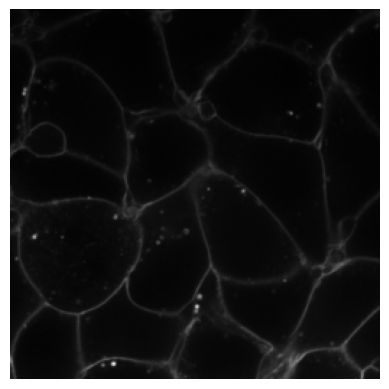

In [ ]:
# Original clean image
plot_image(img3)

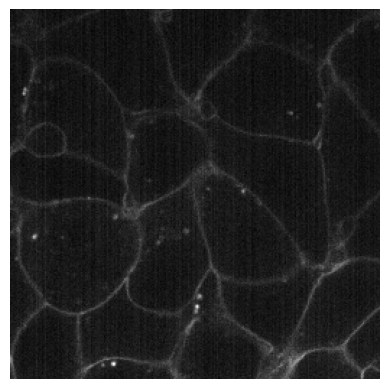

In [ ]:
# Noisy image simulating a CMOS camera
plot_image(RandCameraNoise(camera = 'cmos').encodes(img3))

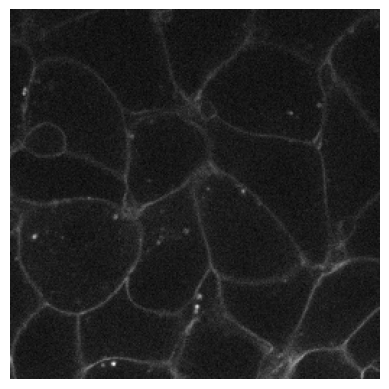

In [ ]:
# Noisy image simulating a CCD camera
plot_image(RandCameraNoise(camera = 'ccd', readout=2).encodes(img3))

In [ ]:
#| export
class Blur(RandTransform):
    """Apply Gaussian blur to the image."""
    split_idx,order = None,1
    def __init__(self, sigma=1.0, ksize=5, prob=0.5):
        store_attr()
        self.p = prob

    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)
        return bioimagetype(GaussianSmooth(self.sigma)(x))
    
    def encodes(self, x: np.ndarray):
        return cv2.GaussianBlur(x, (self.ksize, self.ksize), self.sigma)

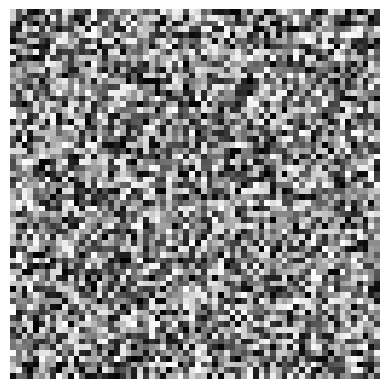

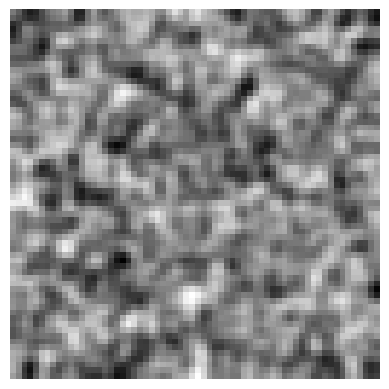

In [ ]:
# Generate a random NumPy array 
random_array = np.random.rand(64, 64)
# Apply Blur transform to the image
blur_transform = Blur(ksize=15, prob=1) 
blurred_nparray = blur_transform(random_array)

# plot the original image
plot_image(random_array)
# Plot the blurred image
plot_image(blurred_nparray)

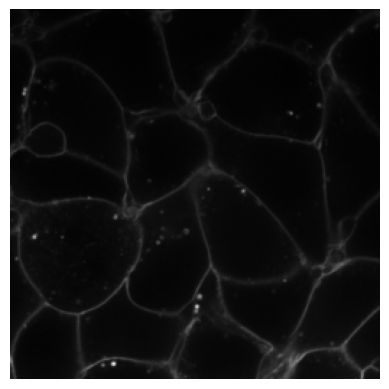

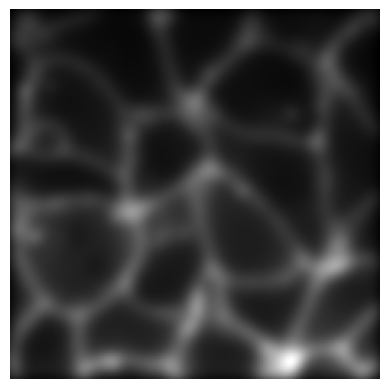

In [ ]:
# Apply Blur transform to the image
blur_transform = Blur(sigma=5, prob=1.0) 
blurred_img = blur_transform(img)

# plot the original image
plot_image(img)
# Plot the blurred image
plot_image(blurred_img)

## Normalization

In [ ]:
#| export
def _scale_intensity_range(x,   # The input image to scale.
                           mi,  # The minimum intensity value.
                           ma,  # The maximum intensity value.
                           eps=1e-20, # A small value to prevent division by zero.
                           dtype=np_float32, # The data type to use for the output image.
                           ):
    if dtype is not None:
        x = x.astype(dtype, copy=False)
        mi = dtype(mi) if isscalar(mi) else mi.astype(dtype, copy=False)
        ma = dtype(ma) if isscalar(ma) else ma.astype(dtype, copy=False)
        eps = dtype(eps)
        x = (x - mi) / (ma - mi + eps)
    return x

In [ ]:
#| export
class ScaleIntensity(Transform):
    """Image normalization."""
    def __init__(x,                 # The input image to scale.
                 min=0.0,           # The minimum intensity value.
                 max=1.0,           # The maximum intensity value.
                 axis=None,         # The axis or axes along which to compute the minimum and maximum values.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply intensity scaling to a BioImageBase object."""
        bioimagetype = type(x)
        y = _scale_intensity_range(x, x.min(), x.max(), eps=self.eps, dtype=self.dtype)
        y *= self.max
        y += self.min
        return bioimagetype(y)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity scaling to a NumPy array."""
        mi = x.min(axis=self.axis, keepdims=True)
        ma = x.max(axis=self.axis, keepdims=True)
        y = (x - mi) / (ma - mi + self.eps)  # Normalize to [0, 1]
        y = y * (self.max - self.min) + self.min  # Scale to [min, max]
        return y.astype(self.dtype)


In [ ]:
#| export
class ScaleIntensityPercentiles(Transform):
    """Percentile-based image normalization."""
    def __init__(x,                 # The input image to scale.
                 pmin=3,            # The minimum percentile value.
                 pmax=99.8,         # The maximum percentile value.
                 axis=None,         # The axis or axes along which to compute the minimum and maximum values.
                 clip=True,         # If True, clips the output values to the specified range.
                 b_min=0.0,         # The minimum intensity value.
                 b_max=1.0,         # The maximum intensity value.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply percentile-based normalization to a BioImageBase object."""
        bioimagetype = type(x)
        mi = percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = percentile(x, self.pmax, axis=self.axis, keepdims=True)
        if self.clip:
            return bioimagetype(np.clip(_scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype), self.b_min, self.b_max))
        return bioimagetype(_scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype))
    
    def encodes(self, x: np.ndarray):
        """Apply percentile-based normalization to a NumPy array."""
        mi = np.percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = np.percentile(x, self.pmax, axis=self.axis, keepdims=True)
        scaled = (x - mi) / (ma - mi + self.eps)
        scaled = scaled.astype(self.dtype)

        if self.clip:
            return np.clip(scaled, self.b_min, self.b_max)
        return scaled


In [ ]:
#| export
class ScaleIntensityVariance(Transform):
    """
    Scales the intensity variance of an ND image to a target value.
    """
    def __init__(self, target_variance=1.0, # The desired variance for the scaled intensities.
                 ndim=2, # Number of spatial dimensions in the image.
                 ):
        store_attr()
        
    def encodes(self, x: BioImageBase):
        """Apply intensity variance scaling to a BioImageBase object."""
        bioimagetype = type(x)
        # Calculate the current variance of the image intensities
        mean, variance = torch.mean(x), torch.var(x)
        if variance == 0:
            return bioimagetype(x)  # Avoid division by zero
        # Calculate the scaling factor based on the ratio of target to current variance
        scale_factor = (self.target_variance / variance).sqrt()
        # Apply the scaling factor to each channel in the image
        if x.ndim == self.ndim + 1:  # Check if it's a multi-channel image (e.g., RGB)
            for i in range(x.shape[0]):
                x[i] = (x[i] - mean) * scale_factor
        else:
            x = (x - mean) * scale_factor
        return bioimagetype(x)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity variance scaling to a NumPy array."""
        mean = np.mean(x)
        variance = np.var(x)
        if variance == 0:
            return x  # Avoid division by zero
        scale_factor = np.sqrt(self.target_variance / variance)
        return (x - mean) * scale_factor


In [ ]:

# Example usage with a random tensor of shape (1, 3, 256, 256)
rand_tensor = BioImageBase(torch.rand(1, 3, 256, 256))

transform = ScaleIntensityVariance(ndim=4)

# Apply the transform to the tensor
scaled_tensor = transform(rand_tensor)

print('Original Tensor Variance:', rand_tensor.var().item())
print('Scaled Tensor Variance:', scaled_tensor.var().item())


Original Tensor Variance: 0.0834645926952362
Scaled Tensor Variance: 1.0


## Data Augmentation

In [ ]:
#| export
def _process_sz(size, ndim=3):
    if isinstance(size,int): 
        size=(size,)*ndim
    return fastuple(size)

def _get_sz(x):
    if isinstance(x, tuple): x = x[0]
    if not isinstance(x, Tensor): return fastuple(x.size)
    return fastuple(getattr(x, 'img_size', getattr(x, 'sz', (x.shape[1:])))) # maybe it should swap x and y axes 

In [ ]:
#| hide
# Define a random tensor
orig_size = (10, 8)
rand_tensor = torch.rand(3, *orig_size)  # Random tensor with shape (3, 10, 8)

test_eq((3,)*3,_process_sz(3,ndim=3))
test_eq(orig_size,_get_sz((rand_tensor, rand_tensor)))

In [ ]:
#| export

class RandCrop2D(RandTransform):
    """
    Randomly crops a 2D image to a specified size.

    This transform randomly crops a 2D image to a specified size during training and 
    performs a center crop during validation.
    """
    split_idx,order = None,1
    def __init__(self, 
        size:int|tuple, # Size to crop to, duplicated if one value is specified
        lazy = False,   # a flag to indicate whether this transform should execute lazily or not. Defaults to False
        **kwargs
    ):
        size = _process_sz(size, ndim=2)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, 
        b, 
        split_idx:int # Index of the train/valid dataset
    ):
        "Randomly positioning crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx: self.ctr = (self.orig_sz)//2
        else:
            wd = self.orig_sz[0] - self.size[0]
            hd = self.orig_sz[1] - self.size[1]
            w_rand = (wd, -1) if wd < 0 else (0, wd)
            h_rand = (hd, -1) if hd < 0 else (0, hd)
            self.ctr = fastuple(random.randint(*w_rand)+self.size[0]//2, random.randint(*h_rand)+self.size[1]//2)

    def encodes(self, x: BioImageBase):
        """Apply spatial cropping to a BioImageBase object."""
        bioimagetype = type(x)
        return bioimagetype(SpatialCrop(roi_center=self.ctr, roi_size=self.size, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        half_w, half_h = self.size[0] // 2, self.size[1] // 2
        cx, cy = self.ctr

        # Calculate crop region
        x_start, x_end = max(cx - half_w, 0), min(cx + half_w, x.shape[0])
        y_start, y_end = max(cy - half_h, 0), min(cy + half_h, x.shape[1])

        return x[x_start:x_end, y_start:y_end]

In [ ]:
#| export

class RandCropND(RandTransform):
    """
    Randomly crops an ND image to a specified size.

    This transform randomly crops an ND image to a specified size during training and performs
    a center crop during validation. It supports both 2D and 3D images and videos, assuming
    the first dimension is the batch dimension.
    """

    split_idx,order = None,1
        
    def __init__(self, size: int | tuple, # Size to crop to, duplicated if one value is specified
                 lazy = False,            # a flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        "Randomly position crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx:
            self.tl = tuple((osz - sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
            self.br = tuple((osz + sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
        else:
            tl = [] # top-left corner
            br = [] # bottom-right corner
            # Calculate top-left and bottom-right corner coordinates for random crop
            for osz, sz in zip(self.orig_sz, self.size):
                w_dif = osz - sz
                if w_dif < 0:
                    w_rand = (0, 0) # No random cropping if input size is smaller than crop size
                    sz = osz # Adjust crop size to match input size
                else:
                    w_rand = (0, w_dif)
                rnd = random.randint(*w_rand)
                tl.append(rnd)
                br.append(rnd + sz)
            self.tl = fastuple(*tl)
            self.br = fastuple(*br)

    def encodes(self, x:BioImageBase):
        "Apply spatial crop transformation to the input image."
        bioimagetype = type(x)
        return bioimagetype(SpatialCrop(roi_start=self.tl, roi_end=self.br, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        slices = tuple(slice(t, b) for t, b in zip(self.tl, self.br))
        return x[slices]
    

In [ ]:
# Define a random tensor
orig_size = (65, 65)
rand_tensor = BioImageBase(torch.rand(8, *orig_size))

for i in range(100):
    test_eq((8,64,64),RandCropND((64,64))(rand_tensor).shape)

In [ ]:
#| export

class RandFlip(RandTransform):
    """
    Randomly flips an ND image over a specified axis.
    Works with both NumPy arrays and BioImageBase objects.
    """

    split_idx, order = None, 1

    def __init__(self, 
                 prob=0.1,            # Probability of flipping
                 spatial_axis=None,   # Axes to flip. Default is None (random selection)
                 ndim=2,              # Number of spatial dimensions
                 lazy=False,          # Flag for lazy execution (for BioImageBase)
                 **kwargs):
        store_attr()
        self.p = prob  # Will be set in `before_call`

    def before_call(self, b=None, split_idx: int = 0):
        """Determine whether to apply flipping and choose random axes if needed."""
        super().before_call(b, split_idx)

        # If no specific axis is given, randomly select axes to flip
        if self.spatial_axis is None:
            self.spatial_axis = np.random.choice(
                np.arange(self.ndim), 
                size=np.random.randint(1, self.ndim + 1), 
                replace=False
            )

    def encodes(self, x: BioImageBase):
        """Applies flipping to a  BioImageBase object."""
        bioimagetype = type(x)
        return bioimagetype(Flip(spatial_axis=self.spatial_axis, lazy=self.lazy)(x))

    def encodes(self, x: np.ndarray):
        """Applies flipping to a NumPy array object."""
        for axis in np.atleast_1d(self.spatial_axis):
            x = np.flip(x, axis=axis)
        return x
        

In [ ]:
image = np.random.rand(1, 3, 3)  
flip_transform = RandFlip(prob=1., ndim=2, spatial_axis=1)  
flipped_image = flip_transform(image)
print('original:\n', image)
print('flipped:\n', flipped_image)  
test_eq(image[0,0,0], flipped_image[0,2,0]) # Check if the image is flipped correctly


original:
 [[[0.29327178 0.94846294 0.10037941]
  [0.25419657 0.47321989 0.05830957]
  [0.99404835 0.23688037 0.76725071]]]
flipped:
 [[[0.99404835 0.23688037 0.76725071]
  [0.25419657 0.47321989 0.05830957]
  [0.29327178 0.94846294 0.10037941]]]


In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = BioImageBase(torch.rand(*orig_size))
print('orig tensor: ', rand_tensor, '\n')
for i in range(3):
    print(RandFlip(prob=.75, spatial_axis=None)(rand_tensor))

orig tensor:  metatensor([[[0.3326, 0.2543, 0.4342, 0.3003],
         [0.4832, 0.3760, 0.9370, 0.0354],
         [0.4060, 0.4358, 0.3563, 0.2707],
         [0.6497, 0.5397, 0.2840, 0.4219]]]) 

metatensor([[[0.4219, 0.2840, 0.5397, 0.6497],
         [0.2707, 0.3563, 0.4358, 0.4060],
         [0.0354, 0.9370, 0.3760, 0.4832],
         [0.3003, 0.4342, 0.2543, 0.3326]]])
metatensor([[[0.3003, 0.4342, 0.2543, 0.3326],
         [0.0354, 0.9370, 0.3760, 0.4832],
         [0.2707, 0.3563, 0.4358, 0.4060],
         [0.4219, 0.2840, 0.5397, 0.6497]]])
metatensor([[[0.3326, 0.2543, 0.4342, 0.3003],
         [0.4832, 0.3760, 0.9370, 0.0354],
         [0.4060, 0.4358, 0.3563, 0.2707],
         [0.6497, 0.5397, 0.2840, 0.4219]]])


In [ ]:
#| export
class RandRot90(RandTransform):
    """
    Randomly rotate an ND image by 90 degrees in the plane specified by axes.

    """

    split_idx,order = None,1
        
    def __init__(self, 
                 prob = 0.1,            # Probability of rotating
                 k = 1,                 # Number of times to rotate by 90 degrees. If k is None, it will be set randomly in `before_call`.
                 max_k = 3,             # Max number of times to rotate by 90 degrees
                 spatial_axes = (0, 1), # Spatial axes that define the plane around which to rotate. Default: (0, 1), this are the first two axis in spatial dimensions.
                 ndim = 2,              # Number of spatial dimensions
                 lazy = False,          # Flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        store_attr()
        self.p = prob 
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        super().before_call(b, split_idx)
        if self.k is None:
            self.k = 1 + np.random.randint(self.max_k)
          
    def encodes(self, x:BioImageBase):
        bioimagetype = type(x)
        return bioimagetype(Rotate90(k=self.k, spatial_axes=self.spatial_axes, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        return np.rot90(image, self.k, axes=self.spatial_axes)

In [ ]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = BioImageBase(torch.rand(*orig_size))

print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandRot90(prob=1, k=i+1)(rand_tensor))

orig tensor:  metatensor([[[0.1693, 0.3898, 0.2731, 0.7344],
         [0.9368, 0.3548, 0.9840, 0.4459],
         [0.0521, 0.0972, 0.7799, 0.1550],
         [0.2676, 0.0074, 0.5963, 0.2406]]]) 

metatensor([[[0.7344, 0.4459, 0.1550, 0.2406],
         [0.2731, 0.9840, 0.7799, 0.5963],
         [0.3898, 0.3548, 0.0972, 0.0074],
         [0.1693, 0.9368, 0.0521, 0.2676]]])
metatensor([[[0.2406, 0.5963, 0.0074, 0.2676],
         [0.1550, 0.7799, 0.0972, 0.0521],
         [0.4459, 0.9840, 0.3548, 0.9368],
         [0.7344, 0.2731, 0.3898, 0.1693]]])
metatensor([[[0.2676, 0.0521, 0.9368, 0.1693],
         [0.0074, 0.0972, 0.3548, 0.3898],
         [0.5963, 0.7799, 0.9840, 0.2731],
         [0.2406, 0.1550, 0.4459, 0.7344]]])


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()